# (advanced) using custom subcortical atlas

this notebook demonstrates how to convert a custom subcortical volumetric atlas (such as part of the **AAL3 atlas**) into the 3D surface mesh format required for `yabplot`.

**why convert?**
unlike the cerebral cortex (which is mapped as a continuous 2D sheet), subcortical regions like the thalamus, amygdala, and putamen are 3D structures. `yabplot` visualizes these structures as beautiful 3D surface meshes, but most standard MRI atlases are distributed as 3D volumes made of blocky voxels. 

to plot them, we cannot simply pass the NIfTI file directly. instead, we use the **marching cubes** algorithm to mathematically wrap a tight 3D mesh around the outer boundary of the voxels. we then apply laplacian surface smoothing to remove the jagged edges, and export them as plot-ready surface files.

### inputs and outputs

**we start with:**
1.  **atlas volume (`.nii.gz`):** the 3D NIfTI file where each voxel contains an integer region ID.
2.  **atlas metadata (`.txt`, `.csv`, etc.):** a file listing the string names for each integer ID. *(note: because every atlas creator formats this differently, we will write a quick loop to parse this into a python dictionary before feeding it to the builder).*

**we need to generate:**
1.  **surface meshes (`.vtk`):** a dedicated folder containing individual 3D mesh files for every extracted region. these files are fully smoothed, and ready to be loaded via the `custom_atlas_path` parameter in `plot_subcortical`.

## step 1: configuration & file paths

In [1]:
import os
import yabplot as yab

# define where your source NIfTI and text files are located
# you can download the same atlas for this tutorial in here:
# https://www.gin.cnrs.fr/wp-content/uploads/AAL3v2_for_SPM12.tar.gz
aal_txt = '/Users/to8050an/Developer/yabplot_miscfiles/AAL3/AAL3v1_1mm.nii.txt'
aal_nii = '/Users/to8050an/Developer/yabplot_miscfiles/AAL3/AAL3v1_1mm.nii.gz'

# we will create two different output folders for two separate atlases
# one for full AAL3v1 subcortical atlas and one where we exclude cerebellum
dir_full_subcortical = 'dev/my_custom_atlases/subcortical/AAL3v1'
dir_no_cerebellum = 'dev/my_custom_atlases/subcortical/AAL3v1_nocerebellum'

## step 2: parse the atlas metadata

first, we write a quick loop to parse the atlas' text file into a standard python dictionary mapping integer IDs to region names.

In [2]:
atlas_labels = {}

with open(aal_txt, 'r') as f_in:
    for line in f_in:
        parts = line.strip().split()
        if len(parts) >= 2:
            try:
                rid = int(parts[0])
                name = parts[1].replace(' ', '_').replace('/', '-')
                atlas_labels[rid] = name
            except ValueError:
                continue

print(f"successfully parsed {len(atlas_labels)} total regions from text file.")
print(atlas_labels)

successfully parsed 170 total regions from text file.
{1: 'Precentral_L', 2: 'Precentral_R', 3: 'Frontal_Sup_2_L', 4: 'Frontal_Sup_2_R', 5: 'Frontal_Mid_2_L', 6: 'Frontal_Mid_2_R', 7: 'Frontal_Inf_Oper_L', 8: 'Frontal_Inf_Oper_R', 9: 'Frontal_Inf_Tri_L', 10: 'Frontal_Inf_Tri_R', 11: 'Frontal_Inf_Orb_2_L', 12: 'Frontal_Inf_Orb_2_R', 13: 'Rolandic_Oper_L', 14: 'Rolandic_Oper_R', 15: 'Supp_Motor_Area_L', 16: 'Supp_Motor_Area_R', 17: 'Olfactory_L', 18: 'Olfactory_R', 19: 'Frontal_Sup_Medial_L', 20: 'Frontal_Sup_Medial_R', 21: 'Frontal_Med_Orb_L', 22: 'Frontal_Med_Orb_R', 23: 'Rectus_L', 24: 'Rectus_R', 25: 'OFCmed_L', 26: 'OFCmed_R', 27: 'OFCant_L', 28: 'OFCant_R', 29: 'OFCpost_L', 30: 'OFCpost_R', 31: 'OFClat_L', 32: 'OFClat_R', 33: 'Insula_L', 34: 'Insula_R', 35: 'Cingulate_Ant_L', 36: 'Cingulate_Ant_R', 37: 'Cingulate_Mid_L', 38: 'Cingulate_Mid_R', 39: 'Cingulate_Post_L', 40: 'Cingulate_Post_R', 41: 'Hippocampus_L', 42: 'Hippocampus_R', 43: 'ParaHippocampal_L', 44: 'ParaHippocampal_R', 

## step 3: filtering strategies (include vs. exclude)

many NIfTI atlases (like AAL3 or Brainnetome) contain *both* cortical and subcortical 
regions mixed together. to build a subcortical mesh atlas, we don't want to the entire
cortex, but only regions within the subcortex.

`yabplot` provides optional `include_list` and `exclude_list` parameters. 
- **mixed atlases:** use `include_list` to grab only the deep structures.
- **pure subcortical atlases:** if your nifti file *only* contains subcortical regions, you can leave these parameters blank.

here, we will create two versions of the atlas to demonstrate the flexibility.

## step 3a: creating full subcortical AAL3 atlas (with cerebellum)

--- building atlas 1: full subcortical (using include_list) ---
filtered down to 82 subcortical regions to extract.
extracting: Hippocampus_L (id 41)...
extracting: Hippocampus_R (id 42)...
extracting: Amygdala_L (id 45)...
extracting: Amygdala_R (id 46)...
extracting: Caudate_L (id 75)...
extracting: Caudate_R (id 76)...
extracting: Putamen_L (id 77)...
extracting: Putamen_R (id 78)...
extracting: Pallidum_L (id 79)...
extracting: Pallidum_R (id 80)...
[WARNING] Thalamus_L is empty in the volume!
[WARNING] Thalamus_R is empty in the volume!
extracting: Cerebellum_Crus1_L (id 95)...
extracting: Cerebellum_Crus1_R (id 96)...
extracting: Cerebellum_Crus2_L (id 97)...
extracting: Cerebellum_Crus2_R (id 98)...
extracting: Cerebellum_3_L (id 99)...
extracting: Cerebellum_3_R (id 100)...
extracting: Cerebellum_4_5_L (id 101)...
extracting: Cerebellum_4_5_R (id 102)...
extracting: Cerebellum_6_L (id 103)...
extracting: Cerebellum_6_R (id 104)...
extracting: Cerebellum_7b_L (id 105)...
extract

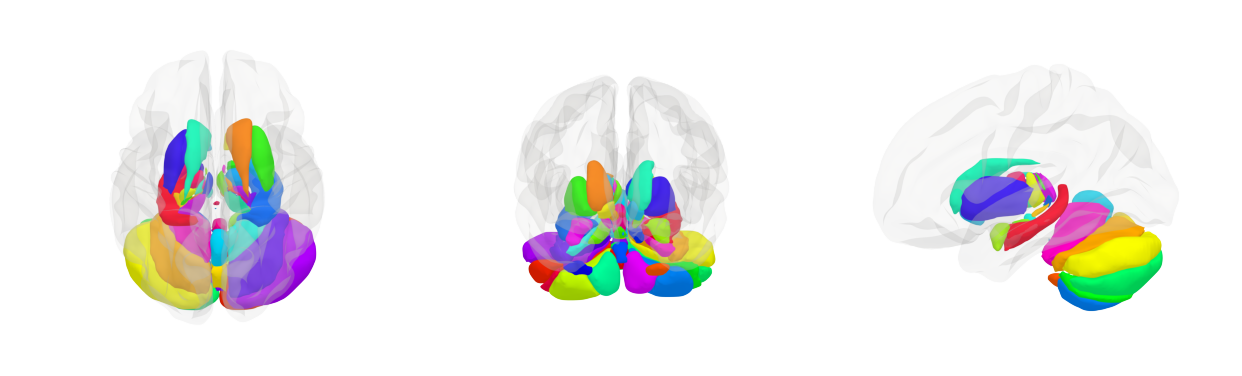

In [3]:
# define all subcortical keywords present in the mixed AAL3 atlas
subcortical_keywords = [
    'Hippocampus', 'Amygdala', 'Caudate', 'Putamen', 'Pallidum', 'Thalamus', 'Thal',
    'Cerebellum', 'Vermis', 'N_Acc', 'VTA', 'SN', 'Red_N', 'LC', 'Raphe'
]

print("--- building atlas 1: full subcortical (using include_list) ---")
yab.build_subcortical_atlas(
    nii_path=aal_nii,
    labels_dict=atlas_labels,
    out_dir=dir_full_subcortical,
    include_list=subcortical_keywords,
    smooth_i=20, smooth_f=0.7
)

# check the amount of regions
regions_full = yab.get_atlas_regions(atlas=None, category='subcortical', custom_atlas_path=dir_full_subcortical)
print(f"full atlas: found {len(regions_full)} meshes.")

# plot the full subcortical atlaas
ax = yab.plot_subcortical(
    custom_atlas_path=dir_full_subcortical,
    views=['superior', 'anterior', 'left_lateral']
)

## step 3b: creating a subcortical AAL3 atlas without cerebellum

the cerebellum is massive and often visually blocks the smaller, deeper nuclei. 
what if we want an atlas without it? 

we can easily pre-filter our python dictionary to only contain subcortical regions, 
and then use the `exclude_list` parameter to drop the cerebellum.


--- building atlas 2: no cerebellum (using exclude_list) ---
filtered down to 56 subcortical regions to extract.
extracting: Hippocampus_L (id 41)...
extracting: Hippocampus_R (id 42)...
extracting: Amygdala_L (id 45)...
extracting: Amygdala_R (id 46)...
extracting: Caudate_L (id 75)...
extracting: Caudate_R (id 76)...
extracting: Putamen_L (id 77)...
extracting: Putamen_R (id 78)...
extracting: Pallidum_L (id 79)...
extracting: Pallidum_R (id 80)...
[WARNING] Thalamus_L is empty in the volume!
[WARNING] Thalamus_R is empty in the volume!
extracting: Thal_AV_L (id 121)...
extracting: Thal_AV_R (id 122)...
extracting: Thal_LP_L (id 123)...
extracting: Thal_LP_R (id 124)...
extracting: Thal_VA_L (id 125)...
extracting: Thal_VA_R (id 126)...
extracting: Thal_VL_L (id 127)...
extracting: Thal_VL_R (id 128)...
extracting: Thal_VPL_L (id 129)...
extracting: Thal_VPL_R (id 130)...
extracting: Thal_IL_L (id 131)...
extracting: Thal_IL_R (id 132)...
extracting: Thal_Re_L (id 133)...
[WARNING] 

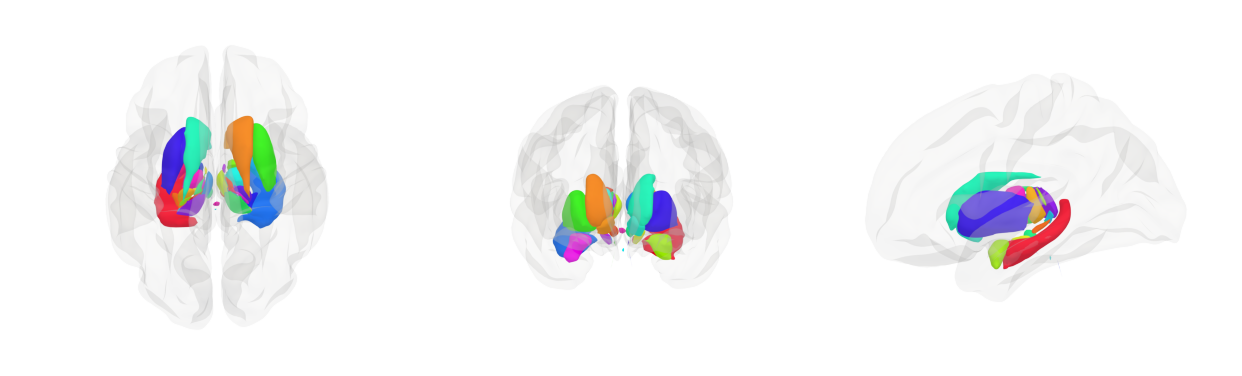

In [4]:
# pre-filter dictionary so no cortical regions remain
only_subcortical_dict = {
    rid: name for rid, name in atlas_labels.items() 
    if any(sub in name for sub in subcortical_keywords)
}

print("\n--- building atlas 2: no cerebellum (using exclude_list) ---")
yab.build_subcortical_atlas(
    nii_path=aal_nii,
    labels_dict=only_subcortical_dict,
    out_dir=dir_no_cerebellum,
    exclude_list=['Cerebellum', 'Vermis'], # ignore these specific keywords
    smooth_i=20, smooth_f=0.5
)

# check the second atlas (no cerebellum)
regions_nocer = yab.get_atlas_regions(atlas=None, category='subcortical', custom_atlas_path=dir_no_cerebellum)
print(f"no cerebellum atlas: found {len(regions_nocer)} meshes.")

# plot atlas without cerebellum
ax = yab.plot_subcortical(
    custom_atlas_path=dir_no_cerebellum,
    views=['superior', 'anterior', 'left_lateral']
)

## step 6: generate quality control (qc) report

building 3D meshes from voxels can occasionally result in artifacts if a region 
in the nifti file is extremely small or fragmented. 

the `qc_custom_subcortical_atlas` tool automatically scans your new `.vtk` files, 
calculates their physical properties (vertex count, face count, and 3d volume in mm³), 
and saves a `.txt` summary. it also loops through the atlas and saves a 
picture of every individual structure so you can quickly scan a folder to ensure 
the smoothing algorithms worked correctly!

In [5]:
from yabplot.atlas_builder import qc_custom_subcortical_atlas

# print("\ngenerating qc report for the no-cerebellum atlas...")
# qc_custom_subcortical_atlas(atlas_dir=dir_no_cerebellum)

# print("generating qc report for the full subcortical atlas...")
# qc_custom_subcortical_atlas(atlas_dir=dir_full_subcortical)

## extra: using custom atlases for white matter tracts

while this tutorial focused on converting and visualizing **subcortical** volumes, `yabplot` supports custom atlases for white matter tracts as well.

this works exactly like the subcortical example above. you simply point `custom_atlas_path` to a folder, and `yabplot` will visualize every tract file it finds there.

* **requirement:** a directory containing `.trk` or `.tck` files.
* **naming:** the filename determines the region name (e.g., `CST_Left.trk` becomes `'CST_Left'`).
* **alignment:** ensure your tract files are in the same space as the background brain (standard MNI152 by default) so they align correctly.